# Argon EEDF with BOLOS

This notebook loads the local Argon cross-section file, sweeps `E/N` from low to high reduced electric field, computes the EEDF for each case, and visualizes EEDF, transport coefficients, and reaction rates.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from argon_eedf_bolos import compute_eedf

In [2]:
cross_section_path = Path("argon cross section.txt")

en_td_values = [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 10.0, 20.0, 40.0, 80.0, 120.0, 200.0, 300.0, 500.0, 750.0, 1000.0, 2000.0, 3000.0]

base_params = {
    "species": "Ar",
    "gas_temperature_k": 300.0,
    "cells": 300,
    "max_energy_ev": 100.0,
    "initial_te_ev": 0.5,
    "max_iterations": 1000,
    "rtol": 1e-8,
}

results = []
for en_td in en_td_values:
    result = compute_eedf(cross_section_path, en_td=en_td, **base_params)
    results.append(result)

len(results)

c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:587: RuntimeWarning: divide by zero encountered in divide
  sigma_tilde = self.sigma_m + nu / np.sqrt(self.benergy) / GAMMA
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: invalid value encountered in log
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: divide by zero encountered in divide
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: divide by zero encountered in log
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\process.py:190: RuntimeWarning: invalid value encountered in add
  A1 = (  expm1a * ag1 + ag
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\process.py:190: RuntimeWarning: invalid value encountered in subtract
  A1 = (  expm1a * a

18

In [3]:
summary_df = pd.DataFrame(
    [
        {
            "species": result["species"],
            "en_td": result["en_td"],
            "gas_temperature_k": result["gas_temperature_k"],
            "mean_energy_eV": result["transport"]["mean_energy_eV"],
            "mobility_n_SI": result["transport"]["mobility_n_SI"],
            "diffusion_n_SI": result["transport"]["diffusion_n_SI"],
        }
        for result in results
    ]
)
summary_df

,species,en_td,gas_temperature_k,mean_energy_eV,mobility_n_SI,diffusion_n_SI
0,Ar,1.0,300.0,2.409539,2.952140e+24,1.208625e+25
1,Ar,1.5,300.0,2.907052,2.156461e+24,1.074051e+25
2,Ar,2.0,300.0,3.314718,1.724745e+24,9.878735e+24
3,Ar,3.0,300.0,3.988682,1.263489e+24,8.774957e+24
4,Ar,4.0,300.0,4.528717,1.041702e+24,8.106419e+24
5,Ar,5.0,300.0,4.883313,9.613099e+23,7.766970e+24
6,Ar,10.0,300.0,5.352426,9.684323e+23,7.515952e+24
7,Ar,20.0,300.0,5.627672,9.402982e+23,7.366729e+24
8,Ar,40.0,300.0,6.005817,8.699053e+23,7.130288e+24
9,Ar,80.0,300.0,6.542464,7.992055e+23,6.826274e+24


In [4]:
eedf_df = pd.concat(
    [
        pd.DataFrame(
            {
                "en_td": result["en_td"],
                "energy_eV": result["energy_eV"],
                "eedf": result["eedf"],
            }
        )
        for result in results
    ],
    ignore_index=True,
)
eedf_df.head()

,en_td,energy_eV,eedf
0,1.0,0.000203,0.211174
1,1.0,0.001016,0.211174
2,1.0,0.002642,0.211174
3,1.0,0.005080,0.211173
4,1.0,0.008332,0.211173


In [5]:
reaction_rates_df = pd.concat(
    [
        pd.DataFrame(result["reaction_rates"]).assign(en_td=result["en_td"])
        for result in results
    ],
    ignore_index=True,
)
reaction_rates_df.head()

,target,process,rate_coefficient_m3_s,en_td
0,Ar,{IONIZATION: Ar -> Ar^+},-3.822014e-30,1.0
1,Ar,{EXCITATION: Ar -> Ar*(11.55eV)},-1.065608e-30,1.0
2,Ar,{EXCITATION: Ar -> Ar*(13.00eV)},-1.953086e-30,1.0
3,Ar,{EXCITATION: Ar -> Ar*(14.00eV)},-7.359947e-31,1.0
4,Ar,{IONIZATION: Ar -> Ar^+},-5.731474e-31,1.5


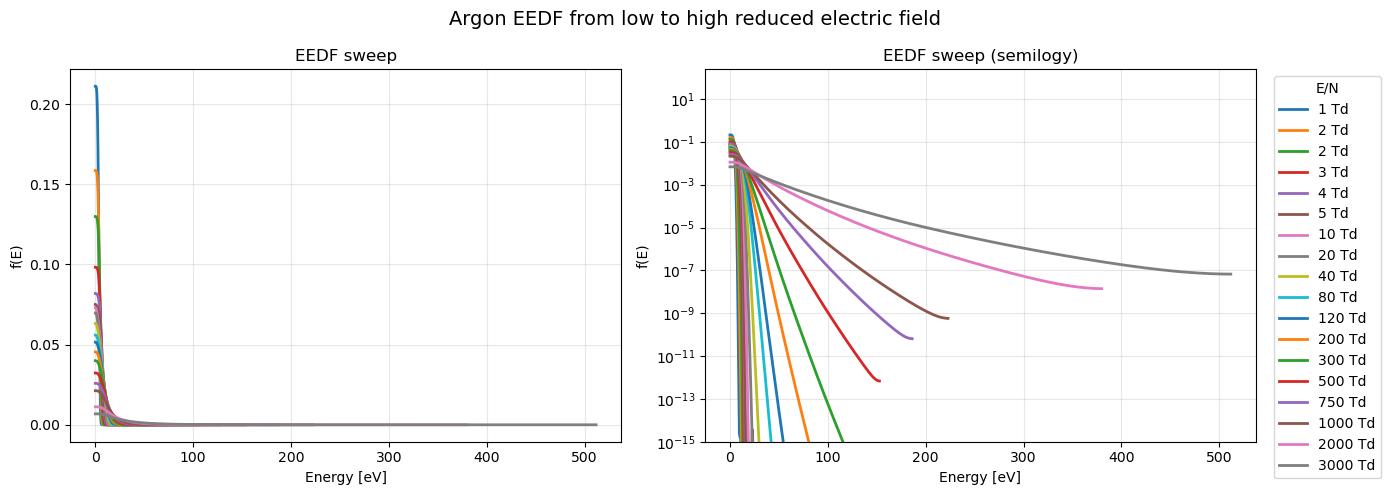

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result in results:
    label = f"{result['en_td']:.0f} Td"
    axes[0].plot(result["energy_eV"], result["eedf"], lw=2, label=label)
    axes[1].semilogy(result["energy_eV"], result["eedf"], lw=2, label=label)

axes[0].set_title("EEDF sweep")
axes[0].set_xlabel("Energy [eV]")
axes[0].set_ylabel("f(E)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("EEDF sweep (semilogy)")
axes[1].set_xlabel("Energy [eV]")
axes[1].set_ylabel("f(E)")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=1e-15)

axes[1].legend(title="E/N", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Argon EEDF from low to high reduced electric field", fontsize=14)
fig.tight_layout()
plt.show()

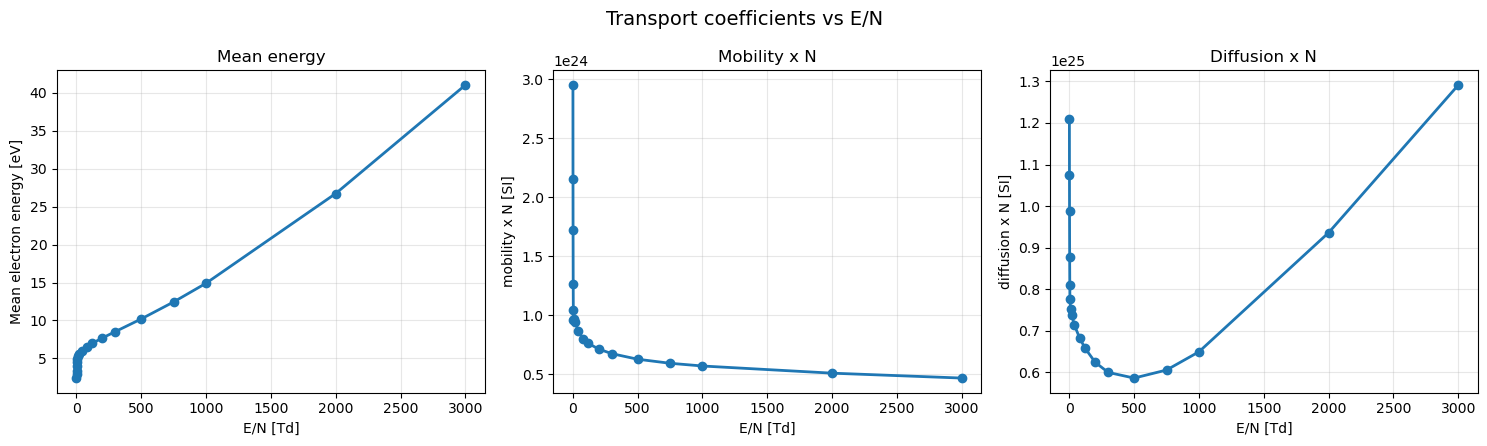

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(summary_df["en_td"], summary_df["mean_energy_eV"], marker="o", lw=2)
axes[0].set_title("Mean energy")
axes[0].set_xlabel("E/N [Td]")
axes[0].set_ylabel("Mean electron energy [eV]")
axes[0].grid(True, alpha=0.3)

axes[1].plot(summary_df["en_td"], summary_df["mobility_n_SI"], marker="o", lw=2)
axes[1].set_title("Mobility x N")
axes[1].set_xlabel("E/N [Td]")
axes[1].set_ylabel("mobility x N [SI]")
axes[1].grid(True, alpha=0.3)

axes[2].plot(summary_df["en_td"], summary_df["diffusion_n_SI"], marker="o", lw=2)
axes[2].set_title("Diffusion x N")
axes[2].set_xlabel("E/N [Td]")
axes[2].set_ylabel("diffusion x N [SI]")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Transport coefficients vs E/N", fontsize=14)
fig.tight_layout()
plt.show()

In [8]:
top_processes = (
    reaction_rates_df.groupby("process")["rate_coefficient_m3_s"]
    .max()
    .sort_values(ascending=False)
    .head(12)
    .index
)

top_reaction_rates_df = reaction_rates_df[reaction_rates_df["process"].isin(top_processes)].copy()
top_reaction_rates_df

,target,process,rate_coefficient_m3_s,en_td
0,Ar,{IONIZATION: Ar -> Ar^+},-3.822014e-30,1.0
1,Ar,{EXCITATION: Ar -> Ar*(11.55eV)},-1.065608e-30,1.0
2,Ar,{EXCITATION: Ar -> Ar*(13.00eV)},-1.953086e-30,1.0
3,Ar,{EXCITATION: Ar -> Ar*(14.00eV)},-7.359947e-31,1.0
4,Ar,{IONIZATION: Ar -> Ar^+},-5.731474e-31,1.5
...,...,...,...,...
67,Ar,{EXCITATION: Ar -> Ar*(14.00eV)},6.680416e-15,2000.0
68,Ar,{IONIZATION: Ar -> Ar^+},6.695864e-14,3000.0
69,Ar,{EXCITATION: Ar -> Ar*(11.55eV)},8.091623e-15,3000.0
70,Ar,{EXCITATION: Ar -> Ar*(13.00eV)},1.317076e-14,3000.0


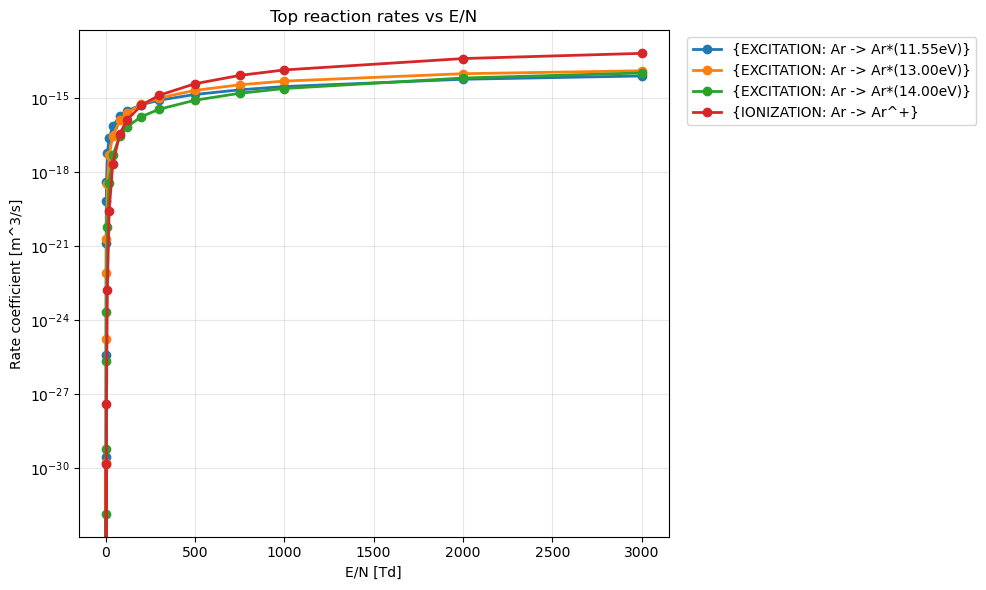

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for process_name, process_df in top_reaction_rates_df.groupby("process"):
    ax.semilogy(process_df["en_td"], process_df["rate_coefficient_m3_s"], marker="o", lw=2, label=process_name)

ax.set_title("Top reaction rates vs E/N")
ax.set_xlabel("E/N [Td]")
ax.set_ylabel("Rate coefficient [m^3/s]")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [10]:
summary_output_csv = Path("argon_eedf_sweep_summary.csv")
eedf_output_csv = Path("argon_eedf_sweep.csv")
reaction_rates_output_csv = Path("argon_reaction_rates_sweep.csv")

summary_df.to_csv(summary_output_csv, index=False)
eedf_df.to_csv(eedf_output_csv, index=False)
reaction_rates_df.to_csv(reaction_rates_output_csv, index=False)

summary_output_csv.resolve(), eedf_output_csv.resolve(), reaction_rates_output_csv.resolve()

(WindowsPath('C:/workspace/argon_eedf_sweep_summary.csv'),
 WindowsPath('C:/workspace/argon_eedf_sweep.csv'),
 WindowsPath('C:/workspace/argon_reaction_rates_sweep.csv'))